In [1]:
!pip install timm torch torchvision tqdm scikit-learn albumentations


Defaulting to user installation because normal site-packages is not writeable
  Using cached timm-1.0.21-py3-none-any.whl.metadata (62 kB)
  Using cached torch-2.9.0-cp310-cp310-manylinux_2_28_x86_64.whl.metadata (30 kB)
  Using cached torchvision-0.24.0-cp310-cp310-manylinux_2_28_x86_64.whl.metadata (5.9 kB)
  Using cached scikit_learn-1.7.2-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (11 kB)
  Using cached albumentations-2.0.8-py3-none-any.whl.metadata (43 kB)
  Using cached huggingface_hub-1.0.1-py3-none-any.whl.metadata (13 kB)
  Using cached safetensors-0.6.2-cp38-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.1 kB)
  Using cached filelock-3.20.0-py3-none-any.whl.metadata (2.1 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.4.2-py3-none-any.whl.metadata (6.3 kB)
  Using cached fsspec-2025.10.0-py3-none-any.whl.metadata (10 kB)
  Using cached nvidia_cuda_nvrtc_cu12-12.8.93-py3-none-manylinux2010_x8

In [4]:
import os

folder_path = "CHC"
count = sum([len(files) for r, d, files in os.walk(folder_path)])
print(f"📊 Total patches: {count}")


📊 Total patches: 16983


In [21]:
import os

# ⚠️ Change this path to your folder
folder_path = "sample23"  # example

# Define which file types to delete
extensions = ('.png', '.jpg', '.jpeg', '.tiff', '.bmp')

deleted = 0

# Loop through all files in the folder
for file in os.listdir(folder_path):
    if file.lower().endswith(extensions):
        file_path = os.path.join(folder_path, file)
        try:
            os.remove(file_path)
            deleted += 1
        except Exception as e:
            print(f"❌ Could not delete {file}: {e}")

print(f"✅ Deleted {deleted} image files from {folder_path}")


FileNotFoundError: [Errno 2] No such file or directory: 'sample23'

In [1]:
import os

# ⚠️ Change this to your folder path
folder_path = "HCC"

# Minimum file size in KB
min_size_kb = 169  

# File extensions to check
extensions = ('.png', '.jpg', '.jpeg', '.tiff', '.bmp')

deleted = 0
skipped = 0

for root, dirs, files in os.walk(folder_path):
    for file in files:
        if file.lower().endswith(extensions):
            file_path = os.path.join(root, file)
            file_size_kb = os.path.getsize(file_path) / 1024  # Convert bytes → KB
            
            if file_size_kb < min_size_kb:
                try:
                    os.remove(file_path)
                    deleted += 1
                except Exception as e:
                    print(f"❌ Could not delete {file}: {e}")
            else:
                skipped += 1

print(f"✅ Deleted {deleted} images smaller than {min_size_kb} KB")
print(f"ℹ️ Skipped {skipped} images (>= {min_size_kb} KB)")


✅ Deleted 234 images smaller than 169 KB
ℹ️ Skipped 16794 images (>= 169 KB)


In [1]:
import os, random, shutil
from sklearn.model_selection import train_test_split

base_dir = ""
balanced_dir = "Balanced"

os.makedirs(balanced_dir, exist_ok=True)

max_count = 17000
labels = ['Normal', 'HCC', 'CHC']

for label in labels:
    src_dir = os.path.join(base_dir, label)
    dst_dir = os.path.join(balanced_dir, label)
    os.makedirs(dst_dir, exist_ok=True)
    
    all_images = [os.path.join(src_dir, f) for f in os.listdir(src_dir) if f.endswith(('.jpg', '.png'))]
    random.shuffle(all_images)
    
    if len(all_images) > max_count:
        selected = all_images[:max_count]
    else:
        selected = all_images
        while len(selected) < max_count:
            selected.append(random.choice(all_images))  # duplicate
    
    for f in selected:
        shutil.copy(f, dst_dir)

print("✅ Balanced dataset created.")



✅ Balanced dataset created.


In [6]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import re
import glob

class HistopathDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.samples = []
        self.transform = transform
        self.labels_map = {'normal':0, 'hcc':1, 'chc':2}
        
        for label_name in self.labels_map.keys():
            folder = os.path.join(root_dir, label_name)
            files = glob.glob(f"{folder}/*.png") + glob.glob(f"{folder}/*.jpg")
            for f in files:
                prefix = re.split(r'[-_]\d+', os.path.basename(f))[0]  # e.g., TCGA-XYZ-1.png → prefix TCGA-XYZ
                self.samples.append((f, self.labels_map[label_name], prefix))
        
        self.prefix_groups = {}
        for f, label, prefix in self.samples:
            if prefix not in self.prefix_groups:
                self.prefix_groups[prefix] = []
            self.prefix_groups[prefix].append((f, label))

    def __len__(self):
        return len(self.prefix_groups)

    def __getitem__(self, idx):
        prefix = list(self.prefix_groups.keys())[idx]
        group = self.prefix_groups[prefix]
        imgs = []
        label = group[0][1]
        for img_path, _ in group[:5]:  # pick up to 5 patches per group
            img = Image.open(img_path).convert("RGB")
            if self.transform:
                img = self.transform(img)
            imgs.append(img)
        imgs = torch.stack(imgs)
        return imgs, label, prefix


In [7]:
import torch
import torch.nn as nn
from torchvision.models import swin_t

class SwinMILModel(nn.Module):
    def __init__(self, num_classes=3):
        super(SwinMILModel, self).__init__()
        
        # Load pretrained Swin Transformer (Tiny version for speed)
        self.backbone = swin_t(weights="IMAGENET1K_V1")
        
        # Replace the classifier head to match your dataset
        in_features = self.backbone.head.in_features
        self.backbone.head = nn.Identity()  # remove original classification head
        
        # Custom classifier for your 3 labels (HCC, CHC, Normal)
        self.classifier = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        feats = self.backbone(x)        # [B, feature_dim]
        out = self.classifier(feats)    # [B, num_classes]
        return out


In [8]:
import os
import torch
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, datasets
import torch.nn as nn



In [9]:
data_dir ="Balanced"  # <-- change to your path


In [10]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),   # Resize all patches
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


In [11]:
import os

base_path ="Balanced"

for root, dirs, files in os.walk(base_path):
    for d in dirs:
        if ".ipynb_checkpoints" in d:
            print("⚠️ Found checkpoint folder at:", os.path.join(root, d))
else:
    print("NOt found")


NOt found


In [16]:
import shutil

for root, dirs, files in os.walk(base_path):
    for d in dirs:
        if ".ipynb_checkpoints" in d:
            path = os.path.join(root, d)
            shutil.rmtree(path)
            print(f"🗑️ Deleted: {path}")


🗑️ Deleted: Balanced/.ipynb_checkpoints


In [21]:
valid_exts = {'.jpg', '.jpeg', '.png', '.tif', '.tiff', '.bmp', '.webp'}

for label in os.listdir(base_path):
    folder = os.path.join(base_path, label)
    if os.path.isdir(folder):
        all_files = os.listdir(folder)
        sample_files = [f for f in all_files if os.path.splitext(f)[1].lower() not in valid_exts]
        if sample_files:
            print(f"⚠️ Non-image files found in {label}: {sample_files[:5]}")
if len(sample_files)==0:
    print("nothing")


nothing


In [12]:
from torchvision.datasets import ImageFolder
from torch.utils.data import random_split
from torchvision import transforms
import os

data_dir ="Balanced"

# Ensure only image folders are used
valid_classes = [d for d in os.listdir(data_dir) 
                 if os.path.isdir(os.path.join(data_dir, d)) and not d.startswith('.')]

print("Valid classes found:", valid_classes)

# Define your transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Load dataset (ignore hidden folders)
full_dataset = ImageFolder(root=data_dir, transform=transform)

# Split into train and validation sets
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])
print(f"✅ Dataset ready — Train: {len(train_dataset)}, Val: {len(val_dataset)}")



Valid classes found: ['HCC', 'CHC', 'Normal']
✅ Dataset ready — Train: 37420, Val: 9355


In [13]:
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

# Assuming your dataset objects are named train_dataset and val_dataset
batch_size = 32  # You can increase this if you have enough GPU memory

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"✅ DataLoaders created successfully: {len(train_loader)} train batches, {len(val_loader)} val batches.")


✅ DataLoaders created successfully: 1170 train batches, 293 val batches.


In [14]:


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SwinMILModel(num_classes=3).to(device)
optimizer = optim.AdamW(model.parameters(), lr=2e-5)
criterion = nn.CrossEntropyLoss()

checkpoint_path = "swin_mil_checkpoint.pth"

# Resume if available
start_epoch = 0
if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model'])
    optimizer.load_state_dict(checkpoint['optimizer'])
    start_epoch = checkpoint['epoch'] + 1
    print(f"✅ Resumed from epoch {start_epoch}")

num_epochs = 10

for epoch in range(start_epoch, num_epochs):
    model.train()
    total_loss = 0
    loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{num_epochs}]")

    for imgs, labels in loop:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    # Save checkpoint
    torch.save({
        'epoch': epoch,
        'model': model.state_dict(),
        'optimizer': optimizer.state_dict()
    }, checkpoint_path)

    print(f"✅ Epoch {epoch+1} completed. Loss: {total_loss/len(train_loader):.4f}")

print("🎯 Training complete and checkpoint saved.")


✅ Resumed from epoch 10
🎯 Training complete and checkpoint saved.


In [15]:
torch.save(model.state_dict(), "swin_mil_final.pth")
print("✅ Final model saved to Google Drive.")


✅ Final model saved to Google Drive.


In [17]:
!pip install seaborn


Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 978.4 kB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.3/112.3 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 4.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 24.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 27.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.0/325.0 kB 34.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 21.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 19.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.9/113.9 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 509.2/509.2 kB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 347.8/347.8 kB 22.2 MB/s e

✅ Validation Accuracy: 95.94%

📊 Classification Report:
               precision    recall  f1-score   support

      Normal       0.87      1.00      0.93      2576
         HCC       1.00      0.89      0.94      3416
         CHC       1.00      1.00      1.00      3363

    accuracy                           0.96      9355
   macro avg       0.96      0.96      0.96      9355
weighted avg       0.96      0.96      0.96      9355



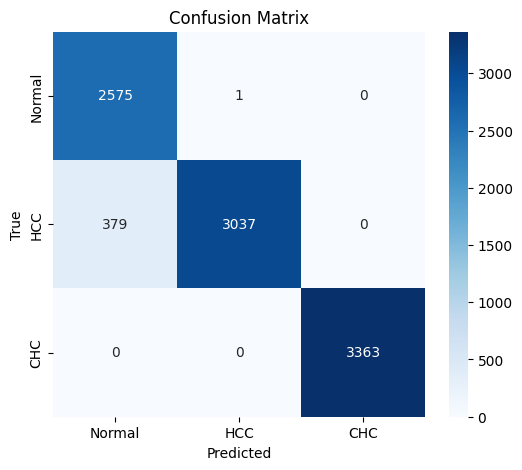

In [18]:
import torch
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Overall accuracy
acc = accuracy_score(all_labels, all_preds)
print(f"✅ Validation Accuracy: {acc*100:.2f}%")

# Classification report
print("\n📊 Classification Report:\n", classification_report(all_labels, all_preds, target_names=['Normal', 'HCC', 'CHC']))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal','HCC','CHC'], yticklabels=['Normal','HCC','CHC'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


In [21]:
!pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 24.1.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.plot(range(1, len(train_losses)+1), train_losses, label='Training Loss')
plt.plot(range(1, len(val_losses)+1), val_losses, label='Validation Loss', linestyle='--')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()


NameError: name 'train_losses' is not defined

<Figure size 800x600 with 0 Axes>

In [ ]:
import pandas as pd

results = classification_report(all_labels, all_preds, target_names=['Normal','HCC','CHC'], output_dict=True)
df = pd.DataFrame(results).transpose()
df.to_csv("evaluation_results.csv", index=True)
print("✅ Results saved to evaluation_results.csv")
